**Nome:** Valdir de Souza Carvalho Neto

**Turma:** SI 241

In [1]:
import numpy as np
from sklearn.datasets import load_iris

dados = load_iris(as_frame=True)
dados = dados.frame

features = [
    "sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"
]

X = dados[features]
y = dados.target

print("Primeiras cinco amostras:")
print(dados.head())

Primeiras cinco amostras:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_treino, X_temp, y_treino, y_temp = train_test_split(
X, y,
test_size=0.30,
random_state=42,
stratify=y)

X_val, X_teste, y_val, y_teste = train_test_split(
X_temp, y_temp,
test_size=0.50,
random_state=42, stratify=y_temp)

print(f"Quantidade de amostras no treino:\n{X_treino.count()}")
print(f"\n\nQuantidade de amostras na validação:\n{X_val.count()}")
print(f"\n\nQuantidade de amostras no teste:\n{X_teste.count()}")

normalizador = StandardScaler()

X_treino = normalizador.fit_transform(X_treino)

X_val = normalizador.transform(X_val)
X_teste = normalizador.transform(X_teste)

Quantidade de amostras no treino:
sepal length (cm)    105
sepal width (cm)     105
petal length (cm)    105
petal width (cm)     105
dtype: int64


Quantidade de amostras na validação:
sepal length (cm)    22
sepal width (cm)     22
petal length (cm)    22
petal width (cm)     22
dtype: int64


Quantidade de amostras no teste:
sepal length (cm)    23
sepal width (cm)     23
petal length (cm)    23
petal width (cm)     23
dtype: int64


In [3]:
from sklearn.neural_network import MLPClassifier

rede_8 = MLPClassifier(
    hidden_layer_sizes=(8,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=500,
    random_state=42
)

rede_8.fit(X_treino, y_treino)

acuracia_treino_8 = rede_8.score(X_treino, y_treino)
acuracia_val_8 = rede_8.score(X_val, y_val)

print(f"Acurácia no treino (8 neurônios): {round(acuracia_treino_8 * 100, 2)}%")
print(f"Acurácia na validação (8 neurônios): {round(acuracia_val_8 * 100, 2)}%")

Acurácia no treino (8 neurônios): 99.05%
Acurácia na validação (8 neurônios): 86.36%


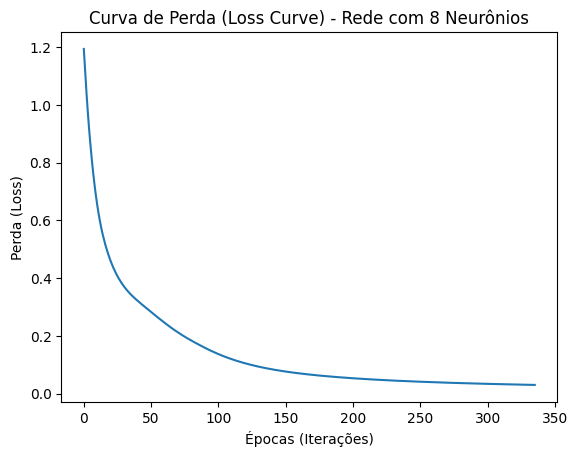

In [4]:
import matplotlib.pyplot as plt

plt.plot(rede_8.loss_curve_)

plt.title("Curva de Perda (Loss Curve) - Rede com 8 Neurônios")
plt.xlabel("Épocas (Iterações)")
plt.ylabel("Perda (Loss)")

plt.show()

In [5]:
rede_16 = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=500,
    random_state=42
)

rede_16.fit(X_treino, y_treino)

acuracia_val_8 = rede_8.score(X_val, y_val)
acuracia_val_16 = rede_16.score(X_val, y_val)

print(f"Acurácia na validação (16 neurônios): {round(acuracia_val_16 * 100, 2)}%")

if acuracia_val_16 > acuracia_val_8:
    print("\nModelo de 16 neurônios escolhido.")
    modelo_escolhido = rede_16
else:
    print("\nModelo de 8 neurônios escolhido.")
    modelo_escolhido = rede_8

Acurácia na validação (16 neurônios): 86.36%

Modelo de 8 neurônios escolhido.


In [6]:
acc_model_esc = modelo_escolhido.score(X_teste, y_teste)

print(f"Acurácia do modelo escolhido no teste: {round(acc_model_esc * 100, 2)}%")


Acurácia do modelo escolhido no teste: 95.65%


In [7]:
previsoes = modelo_escolhido.predict(X_teste[:5])

valores_reais = y_teste[:5].values

print(f"Espécies Previstas: {previsoes}")
print(f"Espécies Reais:   : {valores_reais}")

Espécies Previstas: [0 0 1 1 2]
Espécies Reais:   : [0 0 2 1 2]


#### Quantas entradas e saídas essa rede possui? Qual é o papel da camada oculta? Por que a saída usa Softmax?

A rede possui **4** entradas (*features*) para cada flor, e possui **3** saídas (as 3 possíveis espécies que a flor pode ser classificada). 

A camada oculta é responsável por aprender representações úteis, onde as camadas calculam somas ponderadas (como a ReLU) pata extrair e combinar padrões não-lineares complexos a partir das entradas originais, entregando informações processadas para que a camada de saída possa tomar a decisão final. 

A função Softmax transforma as pontuações das classes em probabilidades e é utilizada na camada de saída de modelos de classificação com três ou mais classes exclusivas. Como está sendo resolvido um problema multiclasse, a função garante que a rede produza probabilidades para cada espécie e que a soma dessas probabilidades seja sempre igual a 1 (100%).

#### A perda diminuiu? Compare treino e validação: há indícios de sobreajuste? Explique em duas frases, sem assumir que apenas reduzir a perda garante um bom modelo.

Sim, o gráfico demonstra que a perda diminuiu ao longo das épocas, o que indica que a rede conseguiu minimizar os erros durante o treinamento. No entanto, a diferença considerável entre a excelente acurácia de treino (99,05%) e a acurácia mais baixa na validação (86,36%) é um indício de sobreajuste, sugerindo que o modelo memorizou os dados de treinamento, mas perdeu parte da capacidade de generalizar para novos dados.